1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

2. Load the Datasets

In [2]:
accidents = pd.read_csv("Accidents_2018.csv")
casualties = pd.read_csv("Casualties_2018.csv")
vehicles = pd.read_csv("Vehicles_2018.csv")

3. Merge the Datasets

In [3]:
print(accidents.shape)
print(casualties.shape)
print(vehicles.shape)

(122635, 32)
(160597, 16)
(226409, 23)


In [4]:
accidents['Accident_Index'] = accidents['Accident_Index'].astype(str)
casualties['Accident_Index'] = casualties['Accident_Index'].astype(str)
vehicles['Accident_Index'] = vehicles['Accident_Index'].astype(str)

df = accidents.merge(casualties, on="Accident_Index", how="left")
df = df.merge(vehicles, on="Accident_Index", how="left")

 Data **Understanding**

In [5]:
df.head()

,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Journey_Purpose_of_Driver,Sex_of_Driver,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type,Vehicle_IMD_Decile
0,2018010080971,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,...,6,1,32,6,1995,2,5,8,1,8
1,2018010080971,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,...,6,1,48,8,1798,8,6,1,1,1
2,2018010080971,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,...,6,1,32,6,1995,2,5,8,1,8
3,2018010080971,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,...,6,1,48,8,1798,8,6,1,1,1
4,2018010080973,542020.0,184290.0,0.046471,51.539651,1,3,1,1,01/01/2018,...,6,3,-1,-1,-1,-1,-1,-1,-1,-1


In [6]:
df.shape

(311415, 69)

In [7]:
df.columns

Index(['Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR',
       'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity',
       'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Day_of_Week',
       'Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)',
       '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit',
       'Junction_Detail', 'Junction_Control', '2nd_Road_Class',
       '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Vehicle_Reference_x',
       'Casualty_Reference', 'Casualty_Class', 'Sex_of_Casualty',
       'Age_of_Casualty', 'Age_Band_of_Casualty', 'Casualty_Severity',
       'Pedestrian_Location', 'Pedestrian_Movem

In [8]:
df.dtypes

Accident_Index             object
Location_Easting_OSGR     float64
Location_Northing_OSGR    float64
Longitude                 float64
Latitude                  float64
                           ...   
Propulsion_Code             int64
Age_of_Vehicle              int64
Driver_IMD_Decile           int64
Driver_Home_Area_Type       int64
Vehicle_IMD_Decile          int64
Length: 69, dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311415 entries, 0 to 311414
Data columns (total 69 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Accident_Index                               311415 non-null  object 
 1   Location_Easting_OSGR                        311283 non-null  float64
 2   Location_Northing_OSGR                       311283 non-null  float64
 3   Longitude                                    311283 non-null  float64
 4   Latitude                                     311283 non-null  float64
 5   Police_Force                                 311415 non-null  int64  
 6   Accident_Severity                            311415 non-null  int64  
 7   Number_of_Vehicles                           311415 non-null  int64  
 8   Number_of_Casualties                         311415 non-null  int64  
 9   Date                                         311415 non-nul

In [10]:
df.describe()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Local_Authority_(District),...,Journey_Purpose_of_Driver,Sex_of_Driver,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type,Vehicle_IMD_Decile
count,311283.000000,3.112830e+05,311283.000000,311283.000000,311415.000000,311415.000000,311415.000000,311415.000000,311415.000000,311415.000000,...,311415.000000,311415.000000,311415.000000,311415.000000,311415.000000,311415.000000,311415.000000,311415.000000,311415.000000,311415.000000
mean,450116.536756,2.839898e+05,-1.282679,52.443210,29.115547,2.770255,2.273298,1.907374,4.092754,336.726333,...,4.701967,1.447088,36.286165,6.069711,1512.910547,1.091842,5.947716,3.680404,0.921327,3.680404
std,95636.710655,1.519308e+05,1.401395,1.368670,24.435361,0.460793,1.134666,1.954528,1.951348,252.567934,...,1.968870,0.643300,20.410540,3.017318,1616.932121,1.425697,6.016891,3.586992,1.083036,3.586992
min,84654.000000,1.023500e+04,-7.266148,49.912362,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,385746.000000,1.758200e+05,-2.214546,51.468753,6.000000,3.000000,2.000000,1.000000,2.000000,102.000000,...,2.000000,1.000000,24.000000,5.000000,898.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,455410.000000,2.337950e+05,-1.183150,51.988808,30.000000,3.000000,2.000000,1.000000,4.000000,322.000000,...,6.000000,1.000000,35.000000,6.000000,1461.000000,1.000000,5.000000,4.000000,1.000000,4.000000
75%,528560.000000,3.891360e+05,-0.147171,53.396557,45.000000,3.000000,2.000000,2.000000,6.000000,516.000000,...,6.000000,2.000000,50.000000,8.000000,1968.000000,2.000000,11.000000,7.000000,1.000000,7.000000
max,655275.000000,1.209512e+06,1.758123,60.763722,98.000000,3.000000,24.000000,59.000000,7.000000,941.000000,...,6.000000,3.000000,101.000000,11.000000,99999.000000,12.000000,84.000000,10.000000,3.000000,10.000000


In [11]:
df.describe(include='object')

,Accident_Index,Date,Time,Local_Authority_(Highway),LSOA_of_Accident_Location
count,311415,311415,311381,311415,295641
unique,122635,365,1438,207,27965
top,2018340K05841,29/06/2018,17:00,E10000016,E01032739
freq,177,1301,2722,10991,292


In [12]:
df.isnull().sum().sort_values(ascending=False)

LSOA_of_Accident_Location    15774
Longitude                      132
Location_Northing_OSGR         132
Latitude                       132
Location_Easting_OSGR          132
                             ...  
Propulsion_Code                  0
Age_of_Vehicle                   0
Driver_IMD_Decile                0
Driver_Home_Area_Type            0
Vehicle_IMD_Decile               0
Length: 69, dtype: int64

In [13]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

LSOA_of_Accident_Location    15774
Location_Easting_OSGR          132
Location_Northing_OSGR         132
Longitude                      132
Latitude                       132
Time                            34
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop(columns=['Accident_Index'], inplace=True)

df.drop_duplicates(inplace=True)

df.dropna(thresh=len(df)*0.5, axis=1, inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

In [16]:
df.isnull().sum().sum()

np.int64(0)

In [17]:
df.head()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,...,Journey_Purpose_of_Driver,Sex_of_Driver,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type,Vehicle_IMD_Decile
0,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,2,...,6,1,32,6,1995,2,5,8,1,8
1,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,2,...,6,1,48,8,1798,8,6,1,1,1
2,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,2,...,6,1,32,6,1995,2,5,8,1,8
3,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,2,...,6,1,48,8,1798,8,6,1,1,1
4,542020.0,184290.0,0.046471,51.539651,1,3,1,1,01/01/2018,2,...,6,3,-1,-1,-1,-1,-1,-1,-1,-1


In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.drop_duplicates(inplace=True)

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [20]:
df.isnull().sum().sum()

np.int64(0)

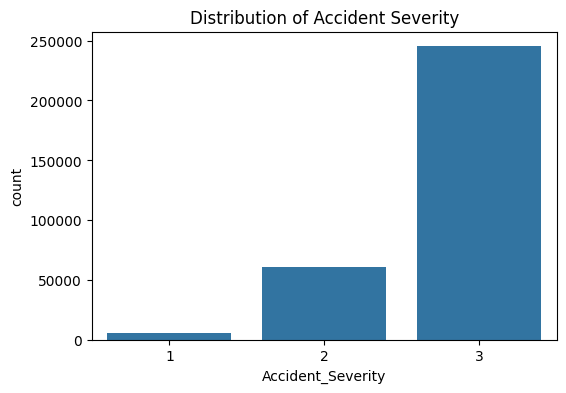

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='Accident_Severity', data=df)
plt.title("Distribution of Accident Severity")
plt.show()

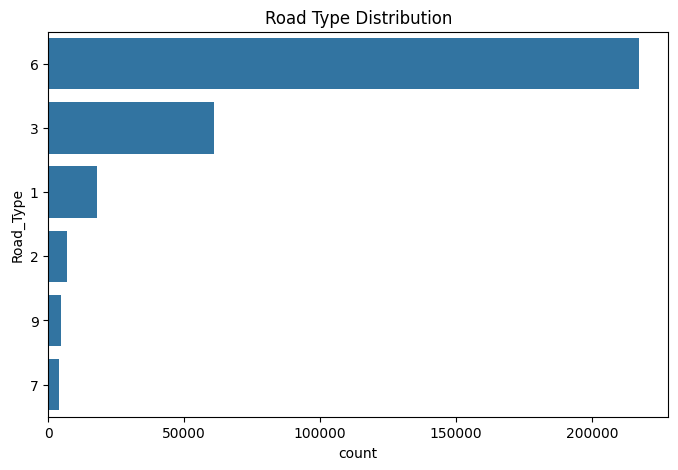

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(y='Road_Type', data=df, order=df['Road_Type'].value_counts().index)
plt.title("Road Type Distribution")
plt.show()

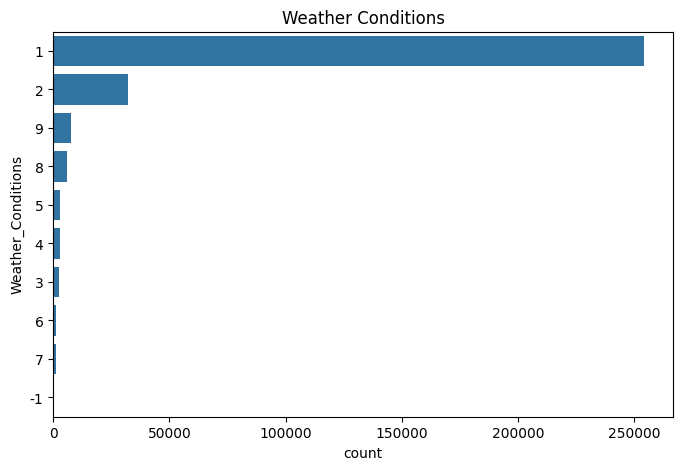

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(y='Weather_Conditions', data=df,
              order=df['Weather_Conditions'].value_counts().index)
plt.title("Weather Conditions")
plt.show()

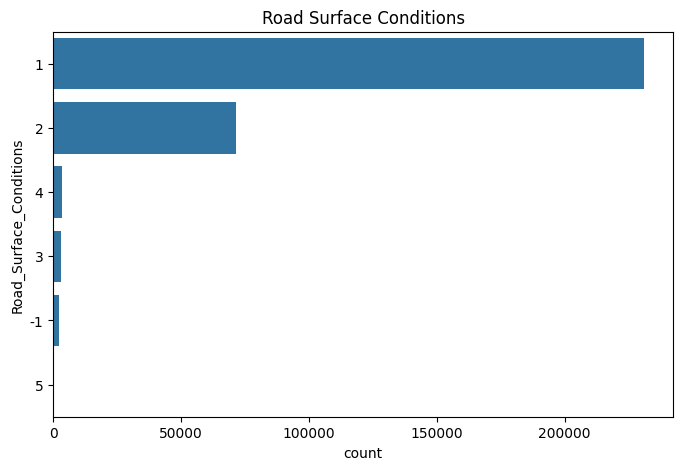

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(y='Road_Surface_Conditions', data=df,
              order=df['Road_Surface_Conditions'].value_counts().index)
plt.title("Road Surface Conditions")
plt.show()

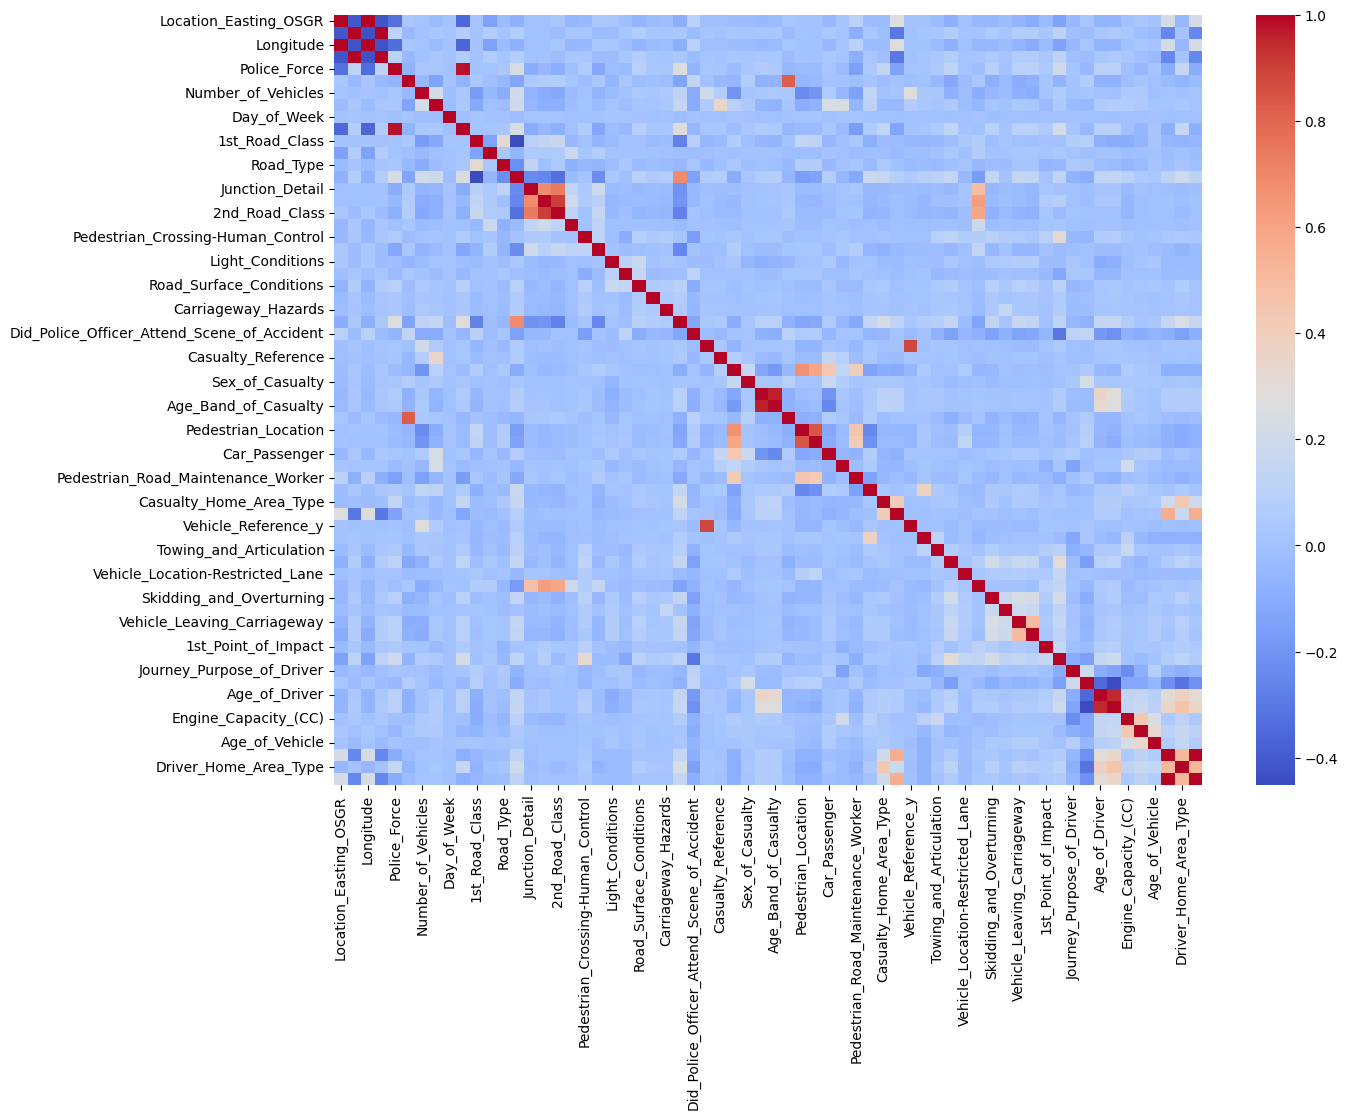

In [25]:
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.show()

solution 1

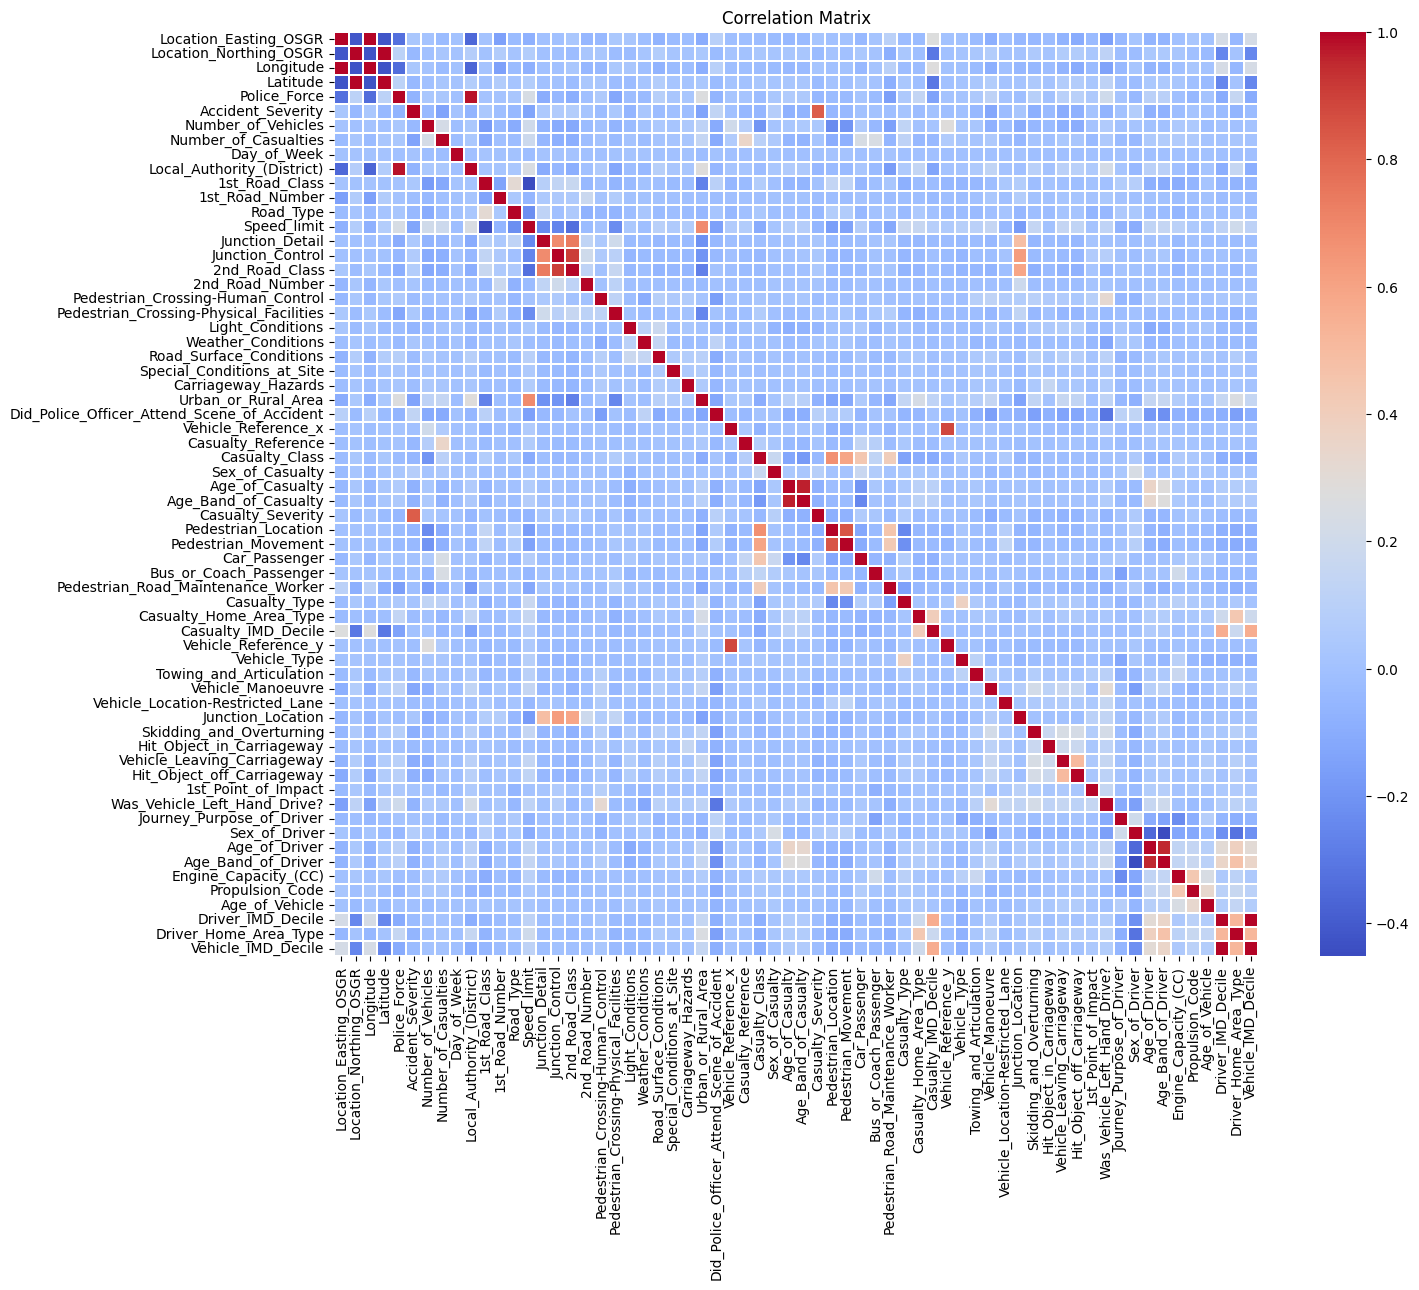

In [26]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(16,12))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    square=True,
    linewidths=0.3
)
plt.title("Correlation Matrix")
plt.show()

solution 2

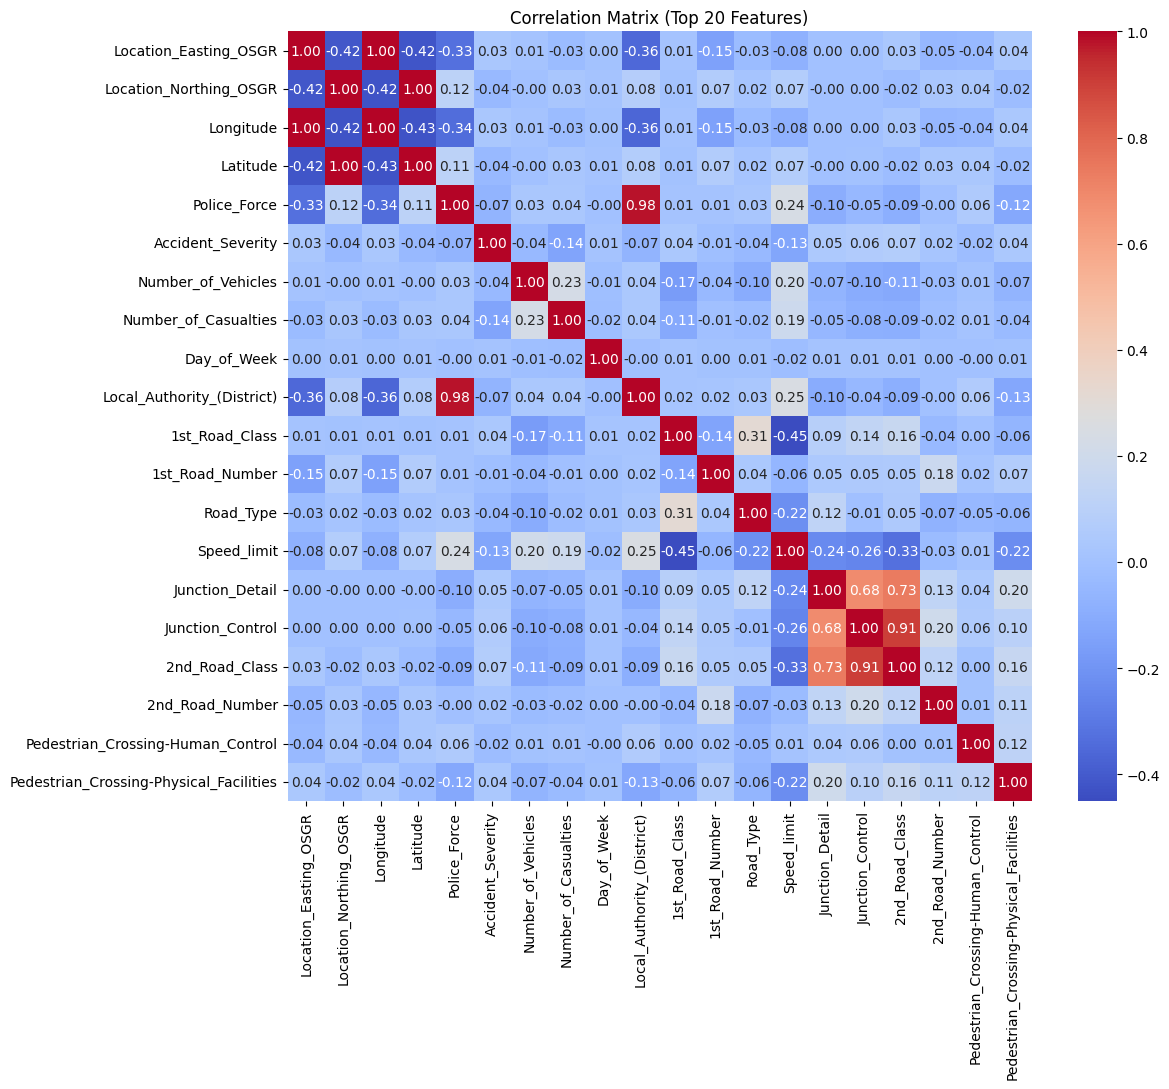

In [27]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr.iloc[:20, :20],
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix (Top 20 Features)")
plt.show()

solution 3

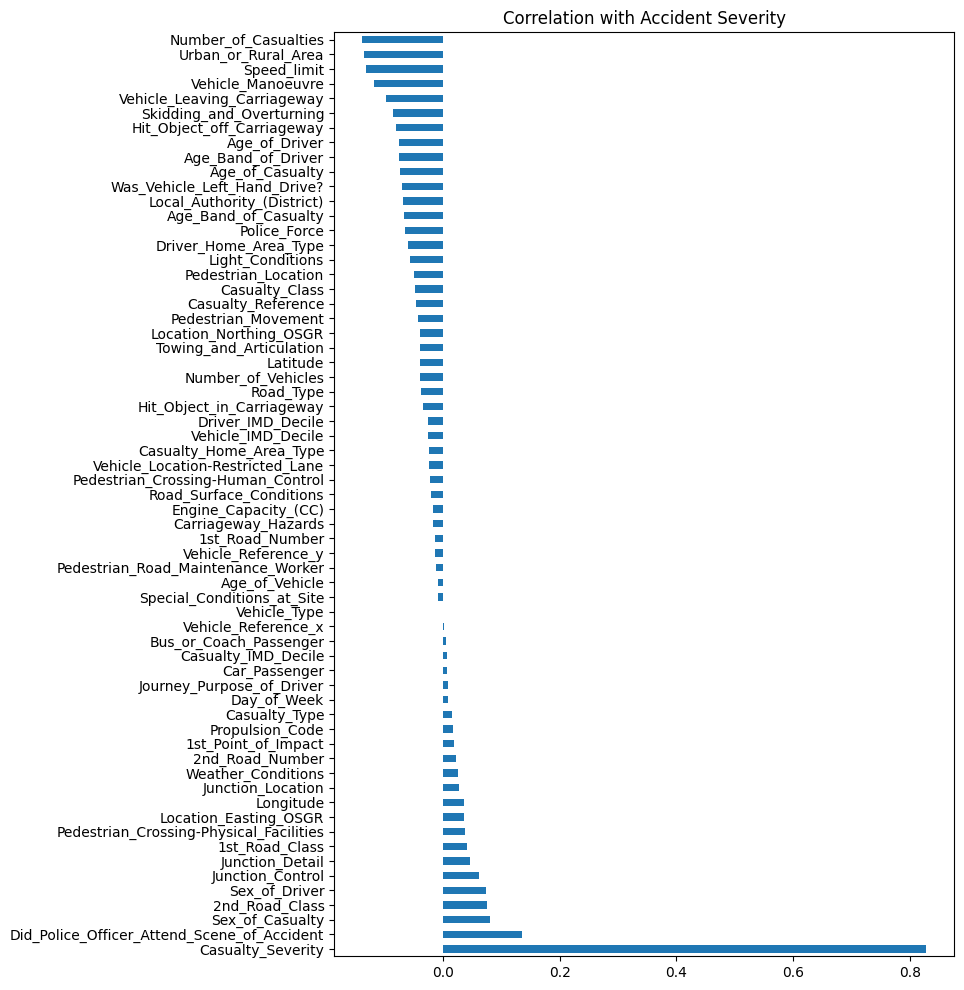

In [28]:
corr_target = df.corr(numeric_only=True)["Accident_Severity"].sort_values(ascending=False)

plt.figure(figsize=(8,12))
corr_target.drop("Accident_Severity").plot(kind="barh")
plt.title("Correlation with Accident Severity")
plt.show()

Part 5: Encoding

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

Part 6 Target

In [30]:
target = "Accident_Severity"

Part 7: X & y

In [31]:
X = df.drop(columns=[target])
y = df[target]

In [32]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(311409, 67)
(311409,)
Accident_Severity
3    245372
2     60530
1      5507
Name: count, dtype: int64


Part 8: Train Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Part 9: Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
y.value_counts()

Accident_Severity
3    245372
2     60530
1      5507
Name: count, dtype: int64

Model 1: Logistic Regression



In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [37]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_lr, average='weighted'))

Accuracy : 0.8700587649722231
Precision: 0.8953937087626446
Recall   : 0.8700587649722231
F1 Score : 0.8799803017699518


In [38]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           1       0.25      0.77      0.38      1101
           2       0.69      0.67      0.68     12106
           3       0.96      0.92      0.94     49075

    accuracy                           0.87     62282
   macro avg       0.63      0.79      0.66     62282
weighted avg       0.90      0.87      0.88     62282



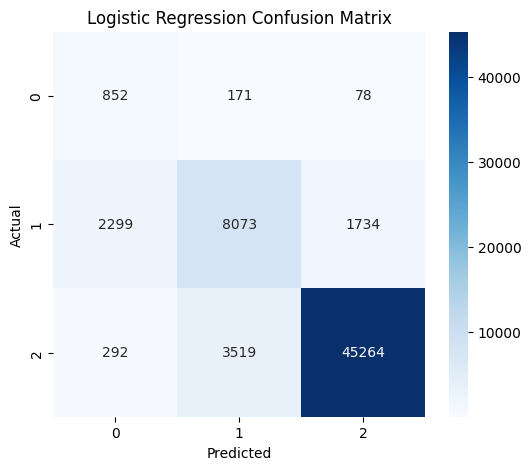

In [39]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
results = []

results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr, average='weighted'),
    recall_score(y_test, y_pred_lr, average='weighted'),
    f1_score(y_test, y_pred_lr, average='weighted')
])

Model 2: K-Nearest Neighbors (KNN)

In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [42]:
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_knn, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_knn, average='weighted'))

Accuracy : 0.9344433383642143
Precision: 0.9339700979257443
Recall   : 0.9344433383642143
F1 Score : 0.930380989937277


In [43]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           1       0.92      0.52      0.67      1101
           2       0.93      0.73      0.82     12106
           3       0.94      0.99      0.96     49075

    accuracy                           0.93     62282
   macro avg       0.93      0.75      0.82     62282
weighted avg       0.93      0.93      0.93     62282



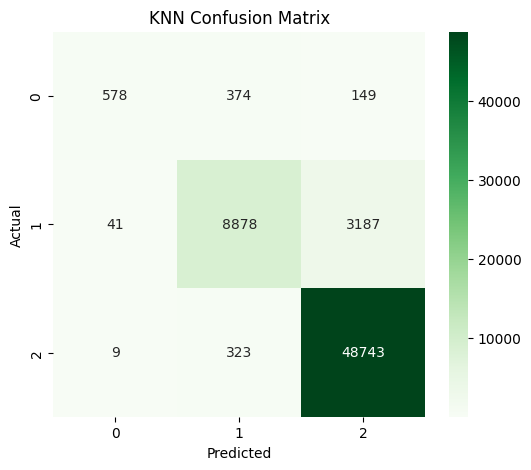

In [44]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [45]:
results.append([
    "KNN",
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn, average='weighted'),
    recall_score(y_test, y_pred_knn, average='weighted'),
    f1_score(y_test, y_pred_knn, average='weighted')
])

Model 3: Support Vector Machine (SVM)

In [46]:
from sklearn.model_selection import train_test_split

X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train,
    y_train,
    train_size=20000,
    stratify=y_train,
    random_state=42
)

In [47]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)

svm.fit(X_train_svm, y_train_svm)

y_pred_svm = svm.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_svm, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_svm, average='weighted'))

Accuracy : 0.9333675861404579
Precision: 0.9313628688903068
Recall   : 0.9333675861404579
F1 Score : 0.9317375292970906


In [49]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           1       0.75      0.61      0.67      1101
           2       0.87      0.79      0.83     12106
           3       0.95      0.98      0.96     49075

    accuracy                           0.93     62282
   macro avg       0.86      0.79      0.82     62282
weighted avg       0.93      0.93      0.93     62282



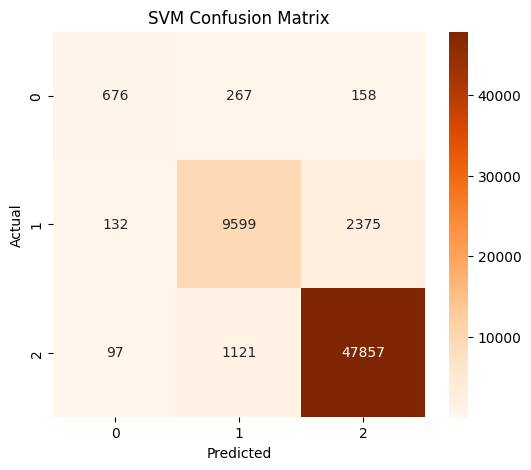

In [50]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [51]:
results.append([
    "SVM",
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm, average='weighted'),
    recall_score(y_test, y_pred_svm, average='weighted'),
    f1_score(y_test, y_pred_svm, average='weighted')
])

Model 4: Decision Tree

In [52]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [53]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_dt, average='weighted'))

Accuracy : 0.9713239780353874
Precision: 0.9711371664197717
Recall   : 0.9713239780353874
F1 Score : 0.971209055758469


In [54]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           1       0.89      0.87      0.88      1101
           2       0.94      0.92      0.93     12106
           3       0.98      0.99      0.98     49075

    accuracy                           0.97     62282
   macro avg       0.94      0.93      0.93     62282
weighted avg       0.97      0.97      0.97     62282



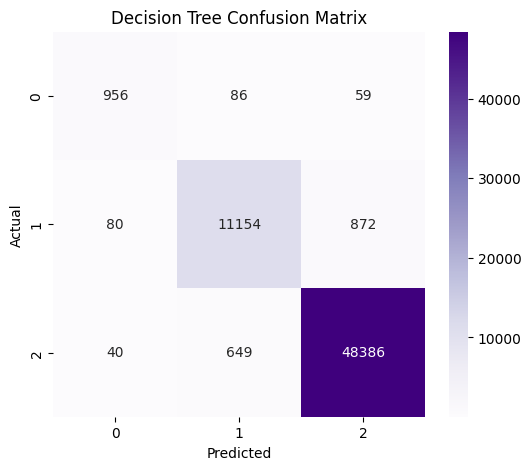

In [55]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
results.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt, average='weighted'),
    recall_score(y_test, y_pred_dt, average='weighted'),
    f1_score(y_test, y_pred_dt, average='weighted')
])

Model 5: Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [58]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_rf, average='weighted'))

Accuracy : 0.974133778619826
Precision: 0.9747516545676026
Recall   : 0.974133778619826
F1 Score : 0.9734848719565851


In [59]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       1.00      0.85      0.92      1101
           2       0.99      0.88      0.93     12106
           3       0.97      1.00      0.98     49075

    accuracy                           0.97     62282
   macro avg       0.99      0.91      0.95     62282
weighted avg       0.97      0.97      0.97     62282



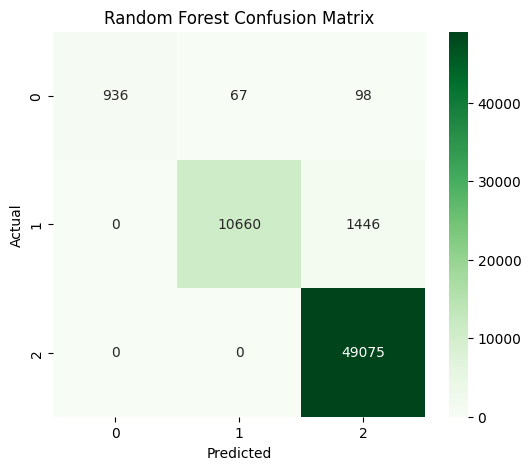

In [60]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf, average='weighted'),
    recall_score(y_test, y_pred_rf, average='weighted'),
    f1_score(y_test, y_pred_rf, average='weighted')
])

Model 6: Gaussian Naive Bayes

In [62]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [63]:
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_nb, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_nb, average='weighted'))

Accuracy : 0.8551427378696895
Precision: 0.9140025800777061
Recall   : 0.8551427378696895
F1 Score : 0.8696928258078215


In [64]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           1       0.12      0.67      0.21      1101
           2       0.88      0.48      0.62     12106
           3       0.94      0.95      0.95     49075

    accuracy                           0.86     62282
   macro avg       0.65      0.70      0.59     62282
weighted avg       0.91      0.86      0.87     62282



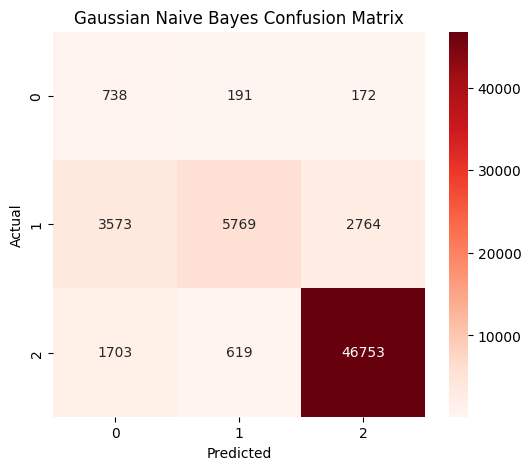

In [65]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [66]:
results.append([
    "Naive Bayes",
    accuracy_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred_nb, average='weighted'),
    recall_score(y_test, y_pred_nb, average='weighted'),
    f1_score(y_test, y_pred_nb, average='weighted')
])

Model 7: AdaBoost

In [67]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

In [68]:
print("Accuracy :", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_ada, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_ada, average='weighted'))

Accuracy : 0.9390192993160142
Precision: 0.9412080542973765
Recall   : 0.9390192993160142
F1 Score : 0.9345881702933313


In [69]:
print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

           1       1.00      0.51      0.67      1101
           2       0.97      0.73      0.83     12106
           3       0.93      1.00      0.97     49075

    accuracy                           0.94     62282
   macro avg       0.97      0.75      0.82     62282
weighted avg       0.94      0.94      0.93     62282



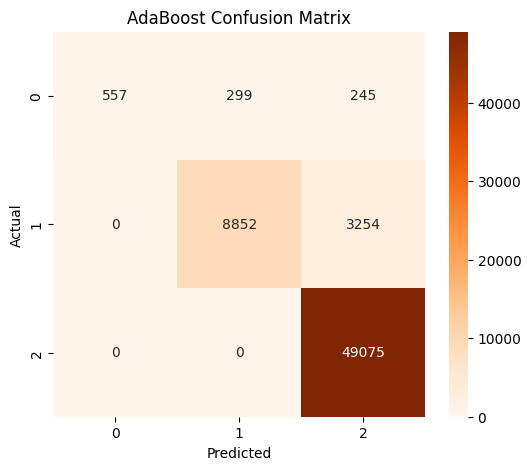

In [70]:
cm = confusion_matrix(y_test, y_pred_ada)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')

plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
results.append([
    "AdaBoost",
    accuracy_score(y_test, y_pred_ada),
    precision_score(y_test, y_pred_ada, average='weighted'),
    recall_score(y_test, y_pred_ada, average='weighted'),
    f1_score(y_test, y_pred_ada, average='weighted')
])

Model 8: Gradient Boosting

In [72]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [73]:
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_gb, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_gb, average='weighted'))

Accuracy : 0.9458591567387046
Precision: 0.9477474885535415
Recall   : 0.9458591567387046
F1 Score : 0.9427491493046078


In [74]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           1       1.00      0.64      0.78      1101
           2       0.97      0.76      0.85     12106
           3       0.94      1.00      0.97     49075

    accuracy                           0.95     62282
   macro avg       0.97      0.80      0.87     62282
weighted avg       0.95      0.95      0.94     62282



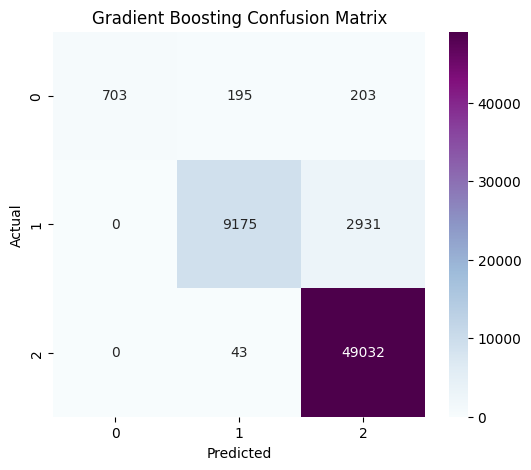

In [75]:
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu')

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [76]:
results.append([
    "Gradient Boosting",
    accuracy_score(y_test, y_pred_gb),
    precision_score(y_test, y_pred_gb, average='weighted'),
    recall_score(y_test, y_pred_gb, average='weighted'),
    f1_score(y_test, y_pred_gb, average='weighted')
])

Model 9: XGBoost

In [78]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 10.1 MB/s eta 0:00:10
   -- ------------------------------------- 6.3/101.7 MB 13.3 MB/s eta 0:00:08
   --- ------------------------------------ 9.7/101.7 MB 14.0 MB/s eta 0:00:07
   ----- ---------------------------------- 12.8/101.7 MB 14.6 MB/s eta 0:00:07
   ------ --------------------------------- 15.7/101.7 MB 14.6 MB/s eta 0:00:06
   ------- -------------------------------- 17.8/101.7 MB 13.7 MB/s eta 0:00:07
   ------- -------------------------------- 19.1/101.7 MB 12.8 MB/s eta 0:00:07
   -------- ------------------------------- 21.5/101.7 MB 12.5 MB/s eta 0:00:07
   --------- ------------------------------ 23.1/101.7 MB 12.5 MB/s eta 0:00:07
   ---------- ----------------------------- 26.7/101.7 MB 12.6 MB/s eta 0:00:06
   ----------- ---------------------------- 28.8/101.7 MB 12.


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)
xgb.fit(X_train, y_train - 1)

y_pred_xgb = xgb.predict(X_test)

In [80]:
print("Accuracy :", accuracy_score(y_test - 1, y_pred_xgb))
print("Precision:", precision_score(y_test - 1, y_pred_xgb, average='weighted'))
print("Recall   :", recall_score(y_test - 1, y_pred_xgb, average='weighted'))
print("F1 Score :", f1_score(y_test - 1, y_pred_xgb, average='weighted'))

Accuracy : 0.960470119777785
Precision: 0.9615908794824537
Recall   : 0.960470119777785
F1 Score : 0.9589722927174491


In [81]:
print(classification_report(y_test - 1, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89      1101
           1       0.98      0.82      0.89     12106
           2       0.96      1.00      0.98     49075

    accuracy                           0.96     62282
   macro avg       0.98      0.87      0.92     62282
weighted avg       0.96      0.96      0.96     62282



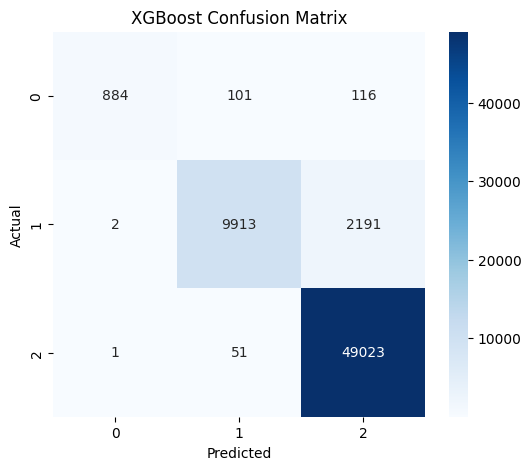

In [82]:
cm = confusion_matrix(y_test - 1, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [83]:
results.append([
    "XGBoost",
    accuracy_score(y_test, y_pred_xgb),
    precision_score(y_test, y_pred_xgb, average='weighted'),
    recall_score(y_test, y_pred_xgb, average='weighted'),
    f1_score(y_test, y_pred_xgb, average='weighted')
])

In [84]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
4,Random Forest,0.974134,0.974752,0.974134,0.973485
3,Decision Tree,0.971324,0.971137,0.971324,0.971209
7,Gradient Boosting,0.945859,0.947747,0.945859,0.942749
6,AdaBoost,0.939019,0.941208,0.939019,0.934588
1,KNN,0.934443,0.933970,0.934443,0.930381
2,SVM,0.933368,0.931363,0.933368,0.931738
0,Logistic Regression,0.870059,0.895394,0.870059,0.879980
5,Naive Bayes,0.855143,0.914003,0.855143,0.869693
8,XGBoost,0.036800,0.008474,0.036800,0.013747


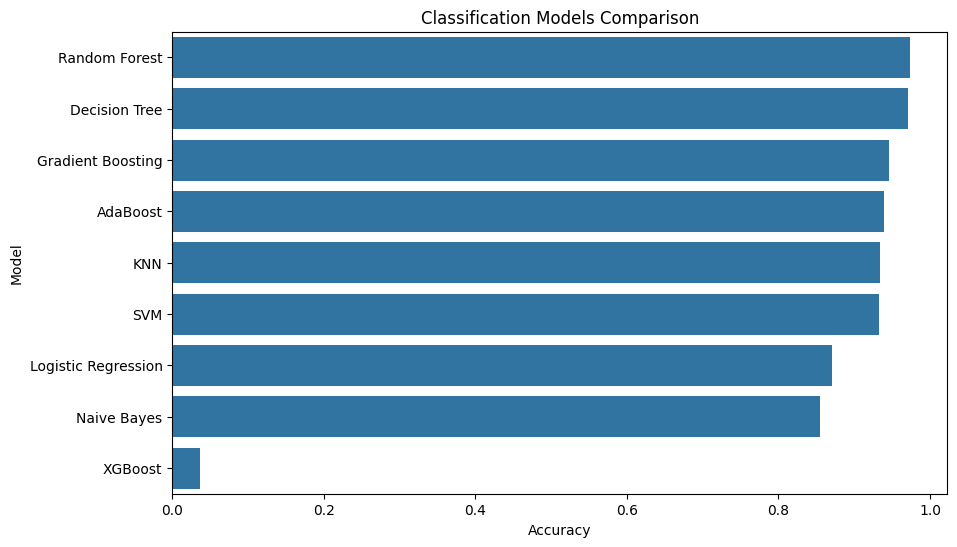

In [85]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Accuracy", y="Model")

plt.title("Classification Models Comparison")
plt.show()

In [87]:
best_model = results_df.iloc[0]

print(best_model)

Model        Random Forest
Accuracy          0.974134
Precision         0.974752
Recall            0.974134
F1-Score          0.973485
Name: 4, dtype: object


In [88]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
0.9657724743322925


In [89]:
y_pred_best = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           1       1.00      0.81      0.90      1101
           2       0.99      0.87      0.93     12106
           3       0.97      1.00      0.98     49075

    accuracy                           0.97     62282
   macro avg       0.99      0.90      0.94     62282
weighted avg       0.97      0.97      0.97     62282



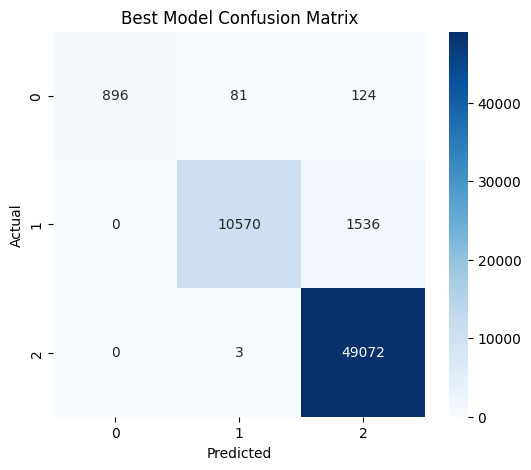

In [90]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Best Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

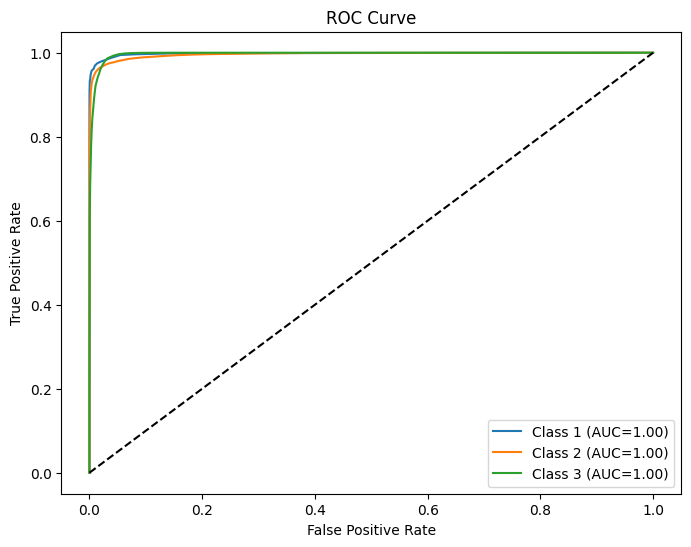

In [91]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[1,2,3])

y_score = best_rf.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i+1} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

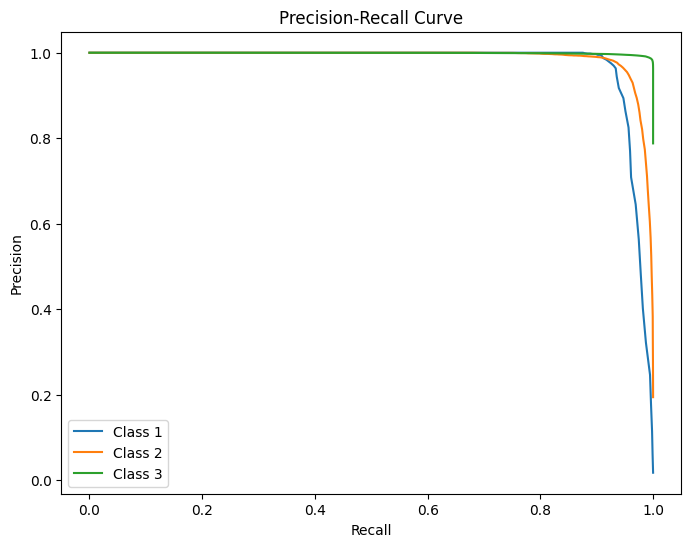

In [92]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for i in range(3):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    plt.plot(recall, precision, label=f"Class {i+1}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

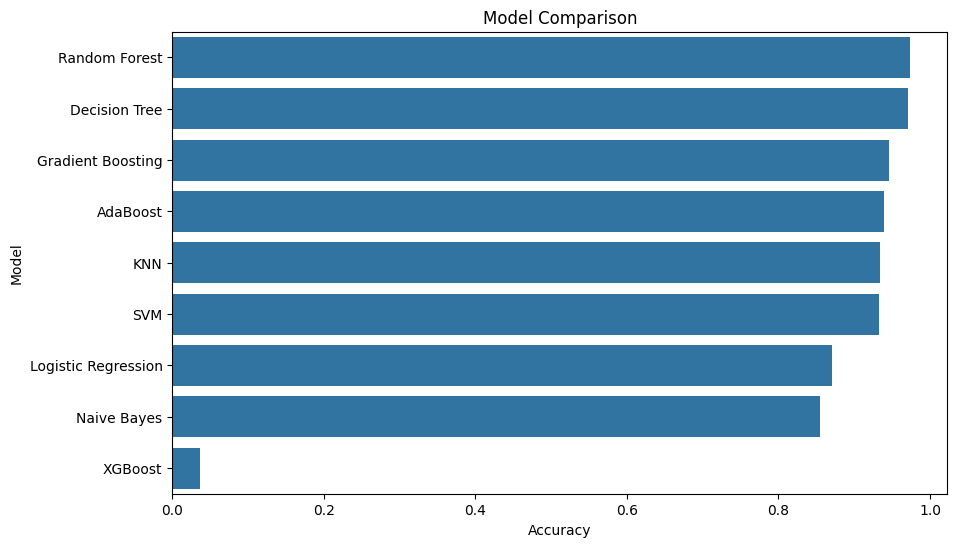

In [93]:
results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1-Score"]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Accuracy", y="Model")

plt.title("Model Comparison")
plt.show()

In [95]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
36,Casualty_Severity,0.573357
6,Number_of_Casualties,0.027920
9,Time,0.018844
29,LSOA_of_Accident_Location,0.016549
7,Date,0.016372
3,Latitude,0.015945
1,Location_Northing_OSGR,0.015845
2,Longitude,0.015445
0,Location_Easting_OSGR,0.015441
10,Local_Authority_(District),0.013087


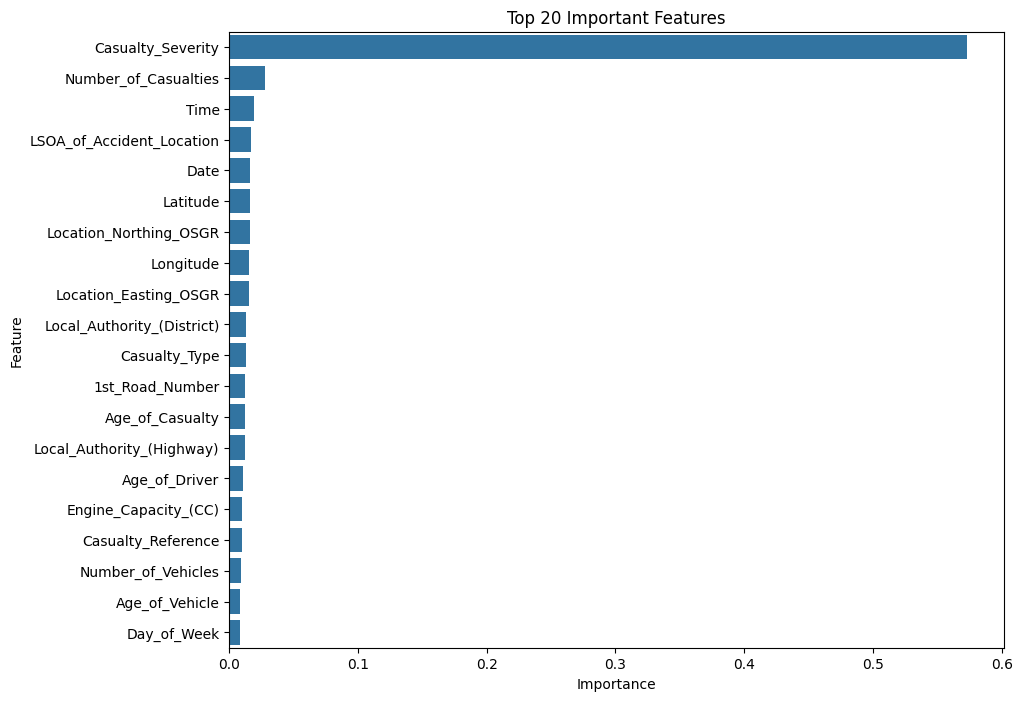

In [96]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")
plt.show()

In [97]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
0.9657724743322925


In [98]:
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test,y_pred_best))

              precision    recall  f1-score   support

           1       1.00      0.81      0.90      1101
           2       0.99      0.87      0.93     12106
           3       0.97      1.00      0.98     49075

    accuracy                           0.97     62282
   macro avg       0.99      0.90      0.94     62282
weighted avg       0.97      0.97      0.97     62282



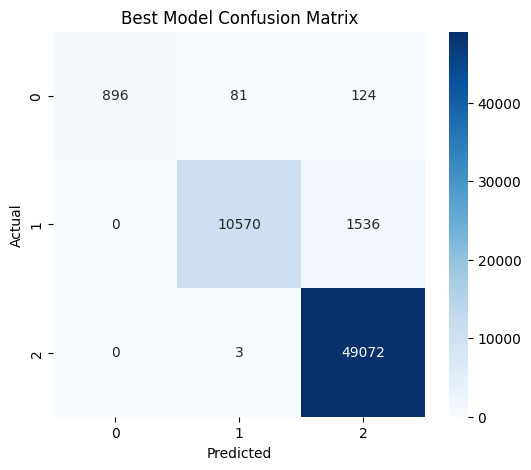

In [99]:
cm = confusion_matrix(y_test,y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Best Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

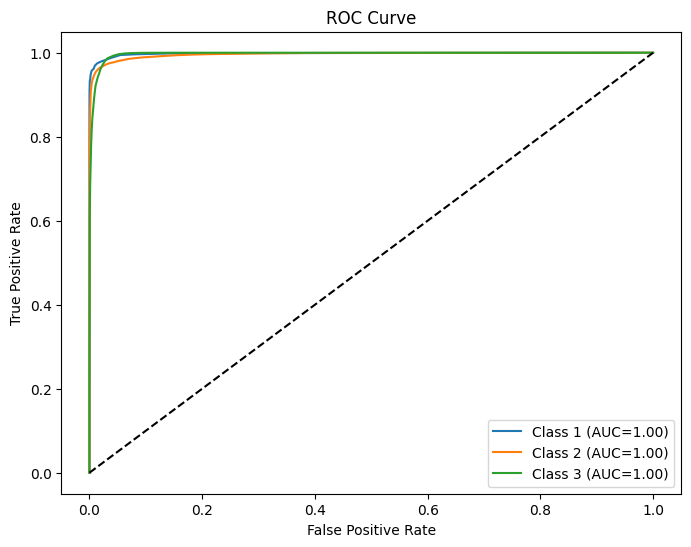

In [100]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = sorted(y.unique())

y_test_bin = label_binarize(y_test, classes=classes)

y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

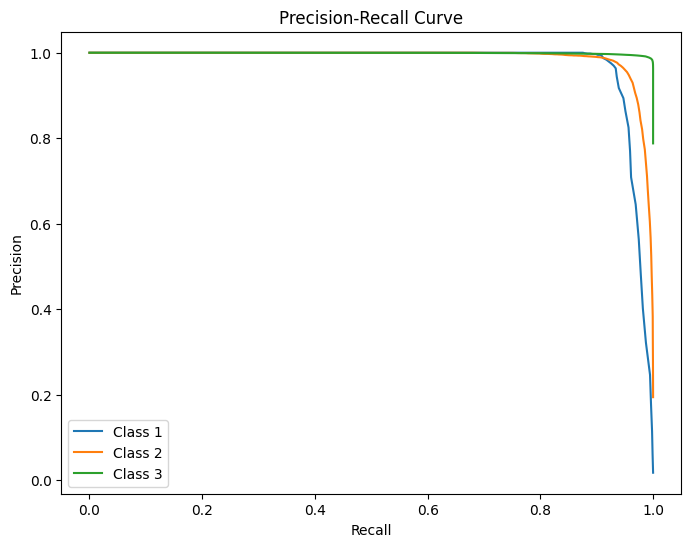

In [101]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    plt.plot(recall, precision, label=f"Class {classes[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()